In [3]:
# Re-run the full pipeline since the kernel was reset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Load the filtered Backdoor attack data
df = pd.read_csv("/content/Backdoor_Attacks.csv")

In [4]:
# Convert timestamp and sort
df['Stime_dt'] = pd.to_datetime(df['Stime'], unit='s', origin='unix')
df = df.sort_values('Stime_dt')
df['time_seconds'] = (df['Stime_dt'] - df['Stime_dt'].iloc[0]).dt.total_seconds()

# Bin into time windows
bin_size = 5
df['time_bin'] = (df['time_seconds'] // bin_size).astype(int)

# Feature columns to use
feature_cols = ['dur', 'sbytes', 'dbytes', 'Spkts', 'Dpkts', 'sttl', 'dttl']

# Aggregate features by bin and count events
bin_counts = df.groupby('time_bin').size().reset_index(name='y')
X_raw = df.groupby('time_bin')[feature_cols].mean().reset_index()
X_raw = pd.merge(X_raw, bin_counts, on='time_bin').fillna(0)

# Extract X and y
X = X_raw[feature_cols].values
y = X_raw['y'].values

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Validation/Test split
N = len(X_scaled)
train_end = int(0.6 * N)
val_end = int(0.8 * N)

X_train, y_train = X_scaled[:train_end], y[:train_end]
X_val, y_val = X_scaled[train_end:val_end], y[train_end:val_end]
X_test, y_test = X_scaled[val_end:], y[val_end:]

# Poisson regression functions
def loss(x, y, w, b):
    y_hat = np.exp(x @ w + b)
    return (y_hat - np.log(y_hat + 1e-8) * y).mean()

def grad(x, y, w, b):
    M, _ = x.shape
    y_hat = np.exp(x @ w + b)
    dw = (x.T @ (y_hat - y)) / M
    db = (y_hat - y).mean()
    return dw, db

def gradient_descent(x, y, w_0, b_0, alpha, num_iter):
    w, b = w_0.copy(), b_0
    hist = np.zeros(num_iter)
    for iter in range(num_iter):
        dw, db = grad(x, y, w, b)
        w -= alpha * dw
        b -= alpha * db
        hist[iter] = loss(x, y, w, b)
    return w, b, hist

In [5]:
# Train model
w_0 = np.zeros(X_train.shape[1])
b_0 = 0
alpha = 0.01
num_iter = 5000
w, b, hist = gradient_descent(X_train, y_train, w_0, b_0, alpha, num_iter)

# Predictions
lambda_train = np.exp(X_train @ w + b)
lambda_val = np.exp(X_val @ w + b)
lambda_test = np.exp(X_test @ w + b)

# Evaluation function
def evaluate_predictions(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    log_likelihood = np.sum(y_true * np.log(y_pred + 1e-6) - y_pred - np.log(np.arange(1, y_true.max()+1)[y_true-1]))
    return rmse, mae, log_likelihood

train_metrics = evaluate_predictions(y_train, lambda_train)
val_metrics = evaluate_predictions(y_val, lambda_val)
test_metrics = evaluate_predictions(y_test, lambda_test)

# Simulate next event arrival time using predicted lambda from latest bin
lambda_next = np.exp(X_test[-1] @ w + b)
predicted_wait_time = np.random.exponential(scale=1/lambda_next)

(train_metrics, val_metrics, test_metrics, predicted_wait_time)

((2.642344926179087, 1.5989166830210655, np.float64(37.26867049605458)),
 (3.4846805300819743, 2.5803862210879442, np.float64(163.28710474059162)),
 (1.5722839398826, 0.926033815258863, np.float64(-70.774414140093)),
 4.318182959550867)

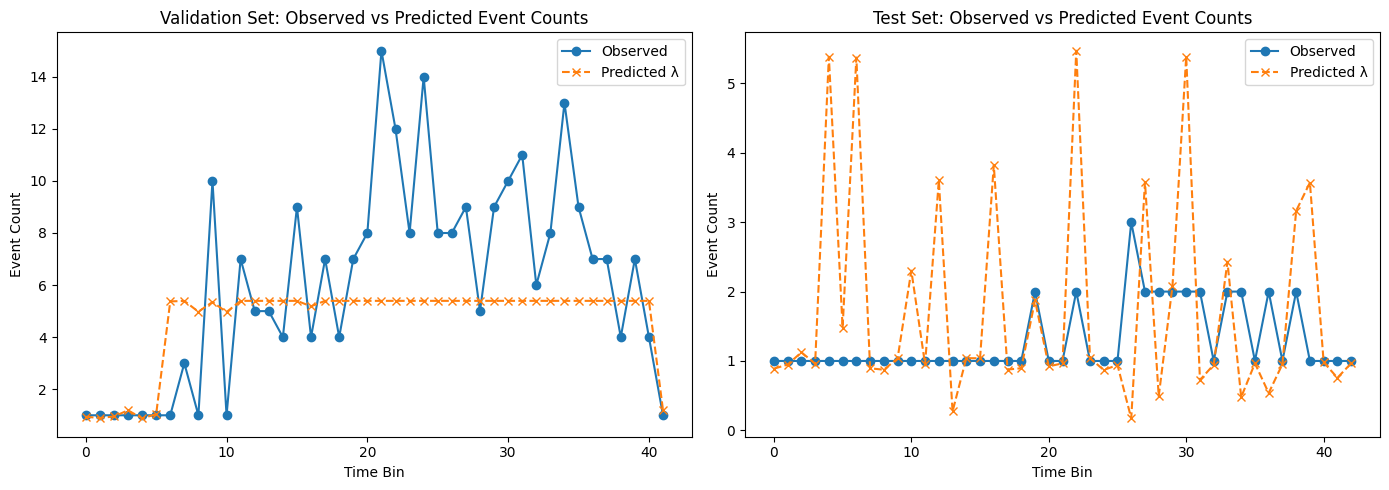

In [6]:
# Plot observed vs predicted event counts for validation and test sets
plt.figure(figsize=(14, 5))

# Validation set
plt.subplot(1, 2, 1)
plt.plot(y_val, label='Observed', marker='o')
plt.plot(lambda_val, label='Predicted λ', linestyle='--', marker='x')
plt.title('Validation Set: Observed vs Predicted Event Counts')
plt.xlabel('Time Bin')
plt.ylabel('Event Count')
plt.legend()

# Test set
plt.subplot(1, 2, 2)
plt.plot(y_test, label='Observed', marker='o')
plt.plot(lambda_test, label='Predicted λ', linestyle='--', marker='x')
plt.title('Test Set: Observed vs Predicted Event Counts')
plt.xlabel('Time Bin')
plt.ylabel('Event Count')
plt.legend()

plt.tight_layout()
plt.show()


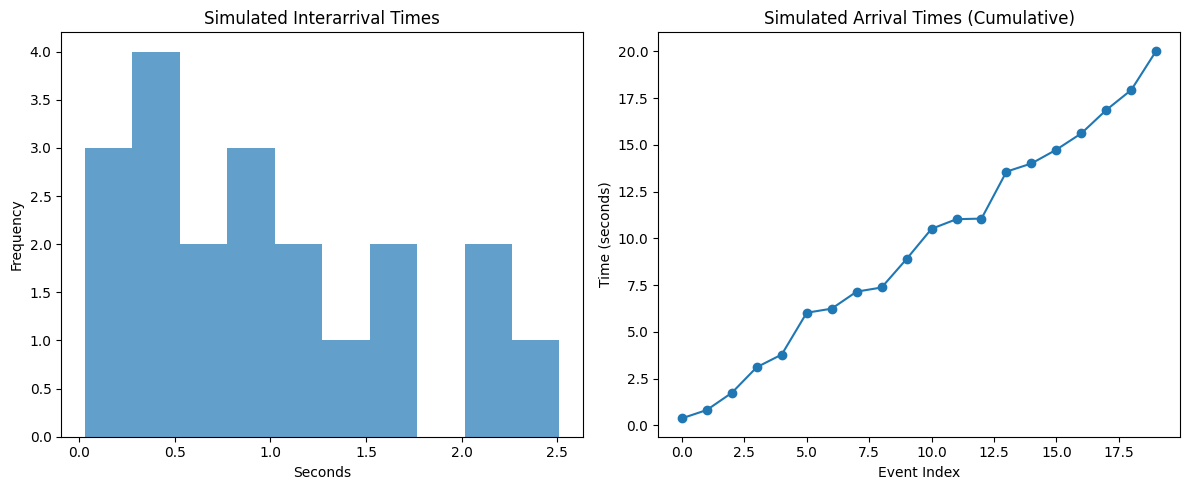

Predicted future attack arrival times (seconds from now):
[ 0.379  0.826  1.743  3.114  3.792  6.025  6.244  7.154  7.376  8.899
 10.513 11.028 11.058 13.57  14.006 14.745 15.617 16.868 17.939 20.035]


In [7]:
# Simulate multiple future event arrival times based on predicted λ
num_simulated_events = 20  # You can change this to simulate more
arrival_times = np.cumsum(np.random.exponential(scale=1/lambda_next, size=num_simulated_events))

# Plot simulated interarrival and arrival times
plt.figure(figsize=(12, 5))

# Interarrival time plot
plt.subplot(1, 2, 1)
plt.hist(np.diff(np.insert(arrival_times, 0, 0)), bins=10, alpha=0.7)
plt.title('Simulated Interarrival Times')
plt.xlabel('Seconds')
plt.ylabel('Frequency')

# Arrival time plot
plt.subplot(1, 2, 2)
plt.plot(arrival_times, marker='o')
plt.title('Simulated Arrival Times (Cumulative)')
plt.xlabel('Event Index')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

# Print the first few predicted arrival times
print("Predicted future attack arrival times (seconds from now):")
print(np.round(arrival_times, 3))